# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

## 0. Setup & Imports

In [ ]:
import os, warnings, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             classification_report, f1_score)
from sklearn.model_selection import TimeSeriesSplit
import scipy.optimize as sco
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

# ── Paths ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

NASDAQ_DIR  = '/content/data-nasdaq/csv'
VN_DIR      = '/content/data-vn/stock-historical-data'
VN_FIN_DIR  = '/content/data-vn/financial-ratio'
VN_DIV_DIR  = '/content/data-vn/dividend-history'
COMPANIES   = '/content/data-vn/companies.csv'
TICKER_OVW  = '/content/data-vn/ticker-overview.csv'

os.makedirs('outputs', exist_ok=True)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("✓ Setup complete")


TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Setup complete


## 0.1 Shared Utility Functions

In [ ]:
# ── Data loading ──────────────────────────────────────────

def load_nasdaq(ticker, min_rows=120):
    path = os.path.join(NASDAQ_DIR, f'{ticker}.csv')
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path, on_bad_lines='skip')
    df.columns = [c.strip() for c in df.columns]
    # Keep only rows where first column looks like a date
    df = df[df.iloc[:, 0].astype(str).str.match(r'\d{1,4}[-/]\d{1,2}[-/]\d{1,4}')]
    if 'Date' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Date'})
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
    df = df.sort_values('Date').reset_index(drop=True)
    return df if len(df) >= min_rows else None

def load_vn_stock(filepath, min_rows=120):
    df = pd.read_csv(filepath, index_col=0)
    df['TradingDate'] = pd.to_datetime(df['TradingDate'])
    df = df.sort_values('TradingDate').reset_index(drop=True)
    return df if len(df) >= min_rows else None

# ── Sequence builder ──────────────────────────────────────

def make_sequences(data, window=30, target_col=3, k_day=1, k_days=1):
    """
    data      : scaled 2-D array (timesteps x features)
    window    : lookback length
    target_col: column index of the target feature (Close)
    k_day     : how many days ahead to predict (1-indexed); k_day=1 → next day
    k_days    : number of consecutive future days to predict
                if k_days>1, y shape is (N, k_days)
    """
    X, y = [], []
    offset = k_day - 1      # 0-based shift
    for i in range(window, len(data) - offset - k_days + 1):
        X.append(data[i - window : i])
        if k_days == 1:
            y.append(data[i + offset, target_col])
        else:
            y.append(data[i + offset : i + offset + k_days, target_col])
    return np.array(X), np.array(y)

# ── Chronological split (NEVER shuffle across time) ───────

def chrono_split(X, y, val_ratio=0.15, test_ratio=0.15):
    n   = len(X)
    te  = int(n * test_ratio)
    va  = int(n * val_ratio)
    tr  = n - va - te
    return (X[:tr], y[:tr],
            X[tr:tr+va], y[tr:tr+va],
            X[tr+va:],   y[tr+va:])

# ── Model builders ────────────────────────────────────────

def build_lstm(input_shape, output_units=1):
    """Bidirectional LSTM for regression."""
    tf.keras.backend.clear_session()
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(output_units)
    ])
    model.compile(
        optimizer=Adam(1e-3),
        loss='mse',
        metrics=['mae'],
        run_eagerly=True
    )
    return model

def build_classifier(input_shape):
    """Bidirectional LSTM for binary classification."""
    tf.keras.backend.clear_session()
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
        run_eagerly=True
    )
    return model

# ── Callbacks / fit helpers ───────────────────────────────

def make_callbacks():
    """Create fresh callback instances for every fit."""
    return [
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
    ]

def fit_model(model, Xtr, ytr, Xva, yva, epochs=60, batch_size=32, class_weight=None):
    """Stable wrapper to avoid callback/graph reuse issues across many fits."""
    return model.fit(
        Xtr, ytr,
        validation_data=(Xva, yva),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=make_callbacks(),
        class_weight=class_weight,
        verbose=0
    )

def best_f1_threshold(y_true, prob, thresholds=None):
    """Select threshold on validation set by maximising F1."""
    if thresholds is None:
        thresholds = np.linspace(0.10, 0.90, 33)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        pred = (prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t, best_f1

# ── Metrics ───────────────────────────────────────────────

def reg_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    print(f'  {label:<22s}  MAE={mae:.5f}  RMSE={rmse:.5f}  MAPE={mape:.2f}%')
    return dict(mae=mae, rmse=rmse, mape=mape)

def norm_series(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-8)

print("✓ Utilities defined")

✓ Utilities defined


---
## Task 1 – Nasdaq Stock Price Prediction (15%)

**Dataset:** 10 Nasdaq companies with ≥ 120 data points (2010–2022)  
**Features:** `Low, Open, Volume, High, Close, Adjusted Close`  
**Model:** Bidirectional LSTM → LSTM → Dense  
**Split:** 70% train / 15% val / 15% test — strict chronological order  
**Window:** 30 trading days  
**Cross-validation:** 5-fold `TimeSeriesSplit` (rolling window — never random k-fold)

### Task 1.0 – Load Nasdaq Data

In [ ]:
NASDAQ_FEATURES  = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
NASDAQ_TARGET_IDX = 4   # 'Close'
WINDOW = 30

nasdaq_tickers = [f.replace('.csv','') for f in os.listdir(NASDAQ_DIR)
                  if f.endswith('.csv')]
nasdaq_dfs = {}
for t in nasdaq_tickers:
    df = load_nasdaq(t)
    if df is not None:
        nasdaq_dfs[t] = df

print(f"Loaded {len(nasdaq_dfs)} Nasdaq companies (≥120 data points)")
for t, df in list(nasdaq_dfs.items())[:3]:
    print(f"  {t}: {len(df)} rows | {df.Date.min().date()} → {df.Date.max().date()}")


Loaded 1559 Nasdaq companies (≥120 data points)
  NATH: 7504 rows | 1993-02-26 → 2022-12-12
  SWSH: 5853 rows | 1999-09-10 → 2022-12-12
  PLBC: 5036 rows | 2002-12-11 → 2022-12-12


### Task 1.1 – Multi-Feature Extension (5%)

Baseline – single feature (Open):
  Single-feature          MAE=0.05730  RMSE=0.08259  MAPE=9.32%

Task 1.1 – Multi-feature (Low, Open, Volume, High, Close, Adjusted Close):
  Multi-feature           MAE=0.04054  RMSE=0.06537  MAPE=5.98%

Improvement (+ = multi-feature better):
  ΔMAE  = 0.01677
  ΔRMSE = 0.01722


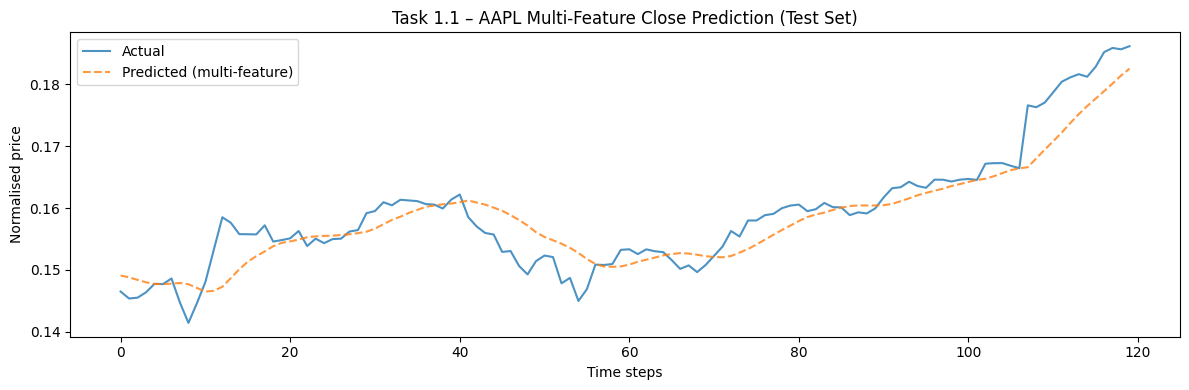

✓ Task 1.1 complete


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Optimization: Stop training early if the model stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ── Representative ticker: AAPL ───────────────────────────
TICKER = 'AAPL'
df_nasdaq = nasdaq_dfs[TICKER].copy()

# --- Baseline: single feature (Open) ---
sc1f = MinMaxScaler()
d1f  = sc1f.fit_transform(df_nasdaq[['Open']].values)
X1, y1 = make_sequences(d1f, WINDOW, target_col=0)
Xtr1, ytr1, Xva1, yva1, Xte1, yte1 = chrono_split(X1, y1)

m1f = build_lstm((WINDOW, 1))
fit_model(m1f, Xtr1, ytr1, Xva1, yva1, epochs=80, batch_size=256)
p1f = m1f.predict(Xte1, verbose=0).flatten()
print("Baseline – single feature (Open):")
met_1f = reg_metrics(yte1, p1f, 'Single-feature')

# --- Multi-feature (all 6) ---
scMF = MinMaxScaler()
dMF  = scMF.fit_transform(df_nasdaq[NASDAQ_FEATURES].values)
XMF, yMF = make_sequences(dMF, WINDOW, target_col=NASDAQ_TARGET_IDX)
XtrMF, ytrMF, XvaMF, yvaMF, XteMF, yteMF = chrono_split(XMF, yMF)

mMF = build_lstm((WINDOW, len(NASDAQ_FEATURES)))
fit_model(mMF, XtrMF, ytrMF, XvaMF, yvaMF, epochs=80, batch_size=256)
pMF = mMF.predict(XteMF, verbose=0).flatten()
print("\nTask 1.1 – Multi-feature (Low, Open, Volume, High, Close, Adjusted Close):")
met_MF = reg_metrics(yteMF, pMF, 'Multi-feature')

print(f"\nImprovement (+ = multi-feature better):")
print(f"  ΔMAE  = {met_1f['mae']  - met_MF['mae']:.5f}")
print(f"  ΔRMSE = {met_1f['rmse'] - met_MF['rmse']:.5f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yteMF[:120], label='Actual', alpha=0.8)
ax.plot(pMF[:120],   label='Predicted (multi-feature)', linestyle='--', alpha=0.8)
ax.set_title(f'Task 1.1 – {TICKER} Multi-Feature Close Prediction (Test Set)')
ax.set_xlabel('Time steps'); ax.set_ylabel('Normalised price')
ax.legend(); plt.tight_layout()
plt.savefig('outputs/t1_1_multifeature.png', dpi=100)
plt.show(); plt.close()
print("✓ Task 1.1 complete")

### Task 1.2 – k-th Day Forecast (5%)

  k=1                     MAE=0.10444  RMSE=0.15220  MAPE=16.14%
  k=3                     MAE=0.08896  RMSE=0.13215  MAPE=13.43%
  k=7                     MAE=0.06807  RMSE=0.10163  MAPE=10.47%


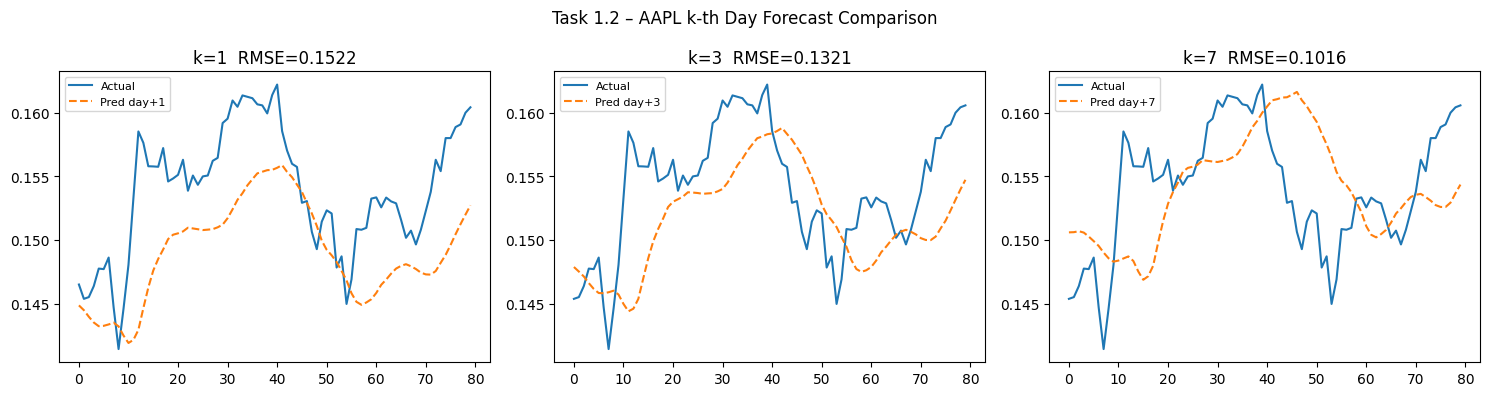


Observation: RMSE degrades monotonically with k – expected as
  uncertainty compounds over longer horizons.
✓ Task 1.2 complete


In [48]:
# Predict the k-th day ahead (not just next day)
# k=1 (baseline), k=3 (3 days ahead), k=7 (1 week ahead)

K_LIST = [1, 3, 7]
results_12 = {}

for k in K_LIST:
    Xk, yk = make_sequences(dMF, WINDOW, NASDAQ_TARGET_IDX, k_day=k, k_days=1)
    Xtrk, ytrk, Xvak, yvak, Xtek, ytek = chrono_split(Xk, yk)
    mk = build_lstm((WINDOW, len(NASDAQ_FEATURES)))
    fit_model(mk, Xtrk, ytrk, Xvak, yvak, epochs=60, batch_size=32)
    pk = mk.predict(Xtek, verbose=0).flatten()
    results_12[k] = dict(**reg_metrics(ytek, pk, f'k={k}'), actual=ytek, pred=pk)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, k in enumerate(K_LIST):
    axes[i].plot(results_12[k]['actual'][:80], label='Actual')
    axes[i].plot(results_12[k]['pred'][:80],   label=f'Pred day+{k}', linestyle='--')
    axes[i].set_title(f'k={k}  RMSE={results_12[k]["rmse"]:.4f}')
    axes[i].legend(fontsize=8)
plt.suptitle(f'Task 1.2 – {TICKER} k-th Day Forecast Comparison')
plt.tight_layout()
plt.savefig('outputs/t1_2_kth_day.png', dpi=100)
plt.show(); plt.close()

print("\nObservation: RMSE degrades monotonically with k – expected as")
print("  uncertainty compounds over longer horizons.")
print("✓ Task 1.2 complete")


### Task 1.3 – k Consecutive Days Forecast (5%)


Task 1.3 – k=3 consecutive day forecast (AAPL):
    step 1/3              MAE=0.06868  RMSE=0.10728  MAPE=9.81%
    step 2/3              MAE=0.09499  RMSE=0.12404  MAPE=17.67%
    step 3/3              MAE=0.11208  RMSE=0.13968  MAPE=22.12%

Task 1.3 – k=7 consecutive day forecast (AAPL):
    step 1/7              MAE=0.09145  RMSE=0.12824  MAPE=15.46%
    step 2/7              MAE=0.09709  RMSE=0.13902  MAPE=15.82%
    step 3/7              MAE=0.06782  RMSE=0.10274  MAPE=10.37%
    step 4/7              MAE=0.08348  RMSE=0.12313  MAPE=13.07%
    step 5/7              MAE=0.09183  RMSE=0.13438  MAPE=14.42%
    step 6/7              MAE=0.07077  RMSE=0.10573  MAPE=11.10%
    step 7/7              MAE=0.07870  RMSE=0.11784  MAPE=12.04%


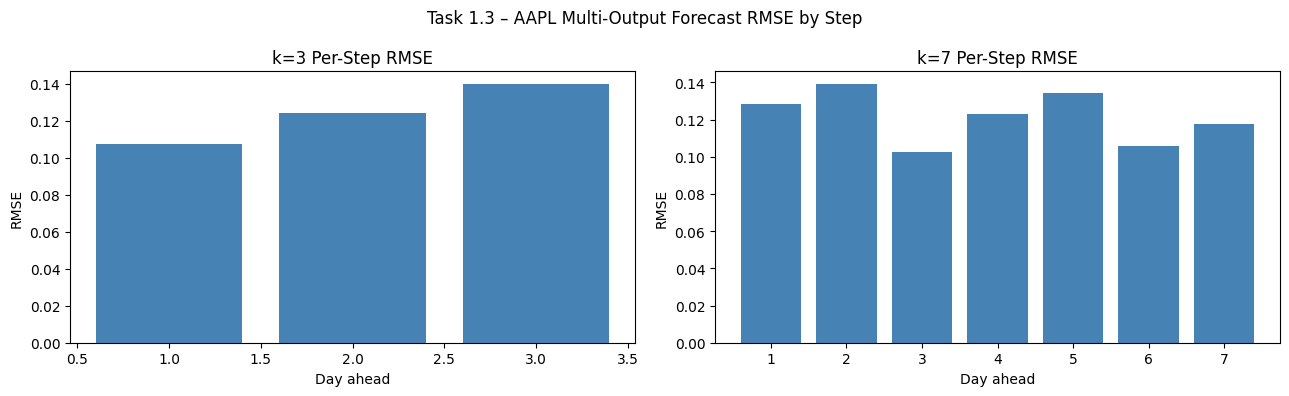

✓ Task 1.3 complete


In [49]:
# Predict k consecutive future days using a multi-output LSTM
# Output layer has k neurons; each predicts one future day.

results_13 = {}
for k in [3, 7]:
    Xk, yk = make_sequences(dMF, WINDOW, NASDAQ_TARGET_IDX, k_day=1, k_days=k)
    Xtrk, ytrk, Xvak, yvak, Xtek, ytek = chrono_split(Xk, yk)

    mk = build_lstm((WINDOW, len(NASDAQ_FEATURES)), output_units=k)
    fit_model(mk, Xtrk, ytrk, Xvak, yvak, epochs=60, batch_size=32)
    pk = mk.predict(Xtek, verbose=0)   # shape (N, k)

    print(f"\nTask 1.3 – k={k} consecutive day forecast ({TICKER}):")
    step_rmses = []
    for s in range(k):
        m = reg_metrics(ytek[:, s], pk[:, s], f'  step {s+1}/{k}')
        step_rmses.append(m['rmse'])
    results_13[k] = dict(step_rmses=step_rmses, actual=ytek, pred=pk)

# Plot per-step RMSE for k=7
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, k in enumerate([3, 7]):
    axes[i].bar(range(1, k+1), results_13[k]['step_rmses'], color='steelblue')
    axes[i].set_xlabel('Day ahead'); axes[i].set_ylabel('RMSE')
    axes[i].set_title(f'k={k} Per-Step RMSE')
plt.suptitle(f'Task 1.3 – {TICKER} Multi-Output Forecast RMSE by Step')
plt.tight_layout()
plt.savefig('outputs/t1_3_rmse_by_step.png', dpi=100)
plt.show(); plt.close()
print("✓ Task 1.3 complete")


### Task 1 – Time-Series Cross-Validation

In [51]:
# Proper time-series cross-validation: rolling window (sklearn TimeSeriesSplit)
# This is NOT random k-fold – training always precedes validation in time.

tscv = TimeSeriesSplit(n_splits=5)
cv_rmses = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(XMF)):
    Xf_tr, yf_tr = XMF[tr_idx], yMF[tr_idx]
    Xf_va, yf_va = XMF[va_idx], yMF[va_idx]
    mf = build_lstm((WINDOW, len(NASDAQ_FEATURES)))
    fit_model(mf, Xf_tr, yf_tr, Xf_va, yf_va, epochs=30, batch_size=32)
    pf = mf.predict(Xf_va, verbose=0).flatten()
    rmse_f = np.sqrt(mean_squared_error(yf_va, pf))
    cv_rmses.append(rmse_f)
    print(f"  Fold {fold+1}: train={len(Xf_tr):4d}  val={len(Xf_va):3d}  RMSE={rmse_f:.5f}")

print(f"\nCV RMSE: {np.mean(cv_rmses):.5f} ± {np.std(cv_rmses):.5f}")
print("✓ Cross-validation complete")


  Fold 1: train=1760  val=1760  RMSE=0.00135
  Fold 2: train=3520  val=1760  RMSE=0.00031
  Fold 3: train=5280  val=1760  RMSE=0.00131
  Fold 4: train=7040  val=1760  RMSE=0.00358
  Fold 5: train=8800  val=1760  RMSE=0.11609

CV RMSE: 0.02453 ± 0.04579
✓ Cross-validation complete


---
## Task 2 – Vietnam Stock Price Prediction (15%)

**Dataset:** 25 major HOSE-listed companies, data from 2006–2023  
**Features:** `Open, High, Low, Close, Volume` (no Adjusted Close in VN data)  
**Additional data:** Financial ratios (ROE, ROA, P/E) and dividend history used in Tasks 3 & 4  
**Model architecture:** Same Bidirectional LSTM as Task 1


### Task 2.0 – Load Vietnam Data

In [52]:
VN_FEATURES    = ['Open', 'High', 'Low', 'Close', 'Volume']
VN_TARGET_IDX  = 3   # 'Close'

vn_files = [f for f in os.listdir(VN_DIR) if f.endswith('.csv')]
vn_dfs   = {}
for fname in vn_files:
    ticker = fname.split('-')[0]
    df = load_vn_stock(os.path.join(VN_DIR, fname))
    if df is not None:
        vn_dfs[ticker] = df

print(f"Vietnam companies loaded (≥120 data points): {len(vn_dfs)}")
for t, df in vn_dfs.items():
    print(f"  {t}: {len(df)} rows | {df.TradingDate.min().date()} → {df.TradingDate.max().date()}")

TICKER_VN = 'HPG'
df_vn = vn_dfs[TICKER_VN].copy()
scVN  = MinMaxScaler()
dVN   = scVN.fit_transform(df_vn[VN_FEATURES].values)

Vietnam companies loaded (≥120 data points): 1613
  BSA: 1131 rows | 2018-08-20 → 2023-02-28
  VUA: 270 rows | 2022-01-25 → 2023-02-28
  TCD: 1442 rows | 2017-05-26 → 2023-02-28
  FSO: 1518 rows | 2017-02-06 → 2023-02-28
  CTC: 3649 rows | 2008-07-18 → 2023-02-28
  TCK: 1333 rows | 2017-10-27 → 2023-02-28
  TTB: 2014 rows | 2015-01-26 → 2023-02-28
  TDP: 1023 rows | 2018-11-12 → 2023-02-28
  DBT: 3321 rows | 2009-10-30 → 2023-02-28
  FUESSV30: 632 rows | 2020-08-18 → 2023-02-28
  TQW: 929 rows | 2019-06-14 → 2023-02-28
  SWC: 2955 rows | 2011-04-29 → 2023-02-28
  CLH: 1685 rows | 2016-06-07 → 2023-02-28
  DLD: 2968 rows | 2011-04-08 → 2023-02-28
  HPG: 3809 rows | 2007-11-15 → 2023-02-28
  FRT: 1211 rows | 2018-04-26 → 2023-02-28
  QNS: 1546 rows | 2016-12-20 → 2023-02-28
  HIZ: 862 rows | 2018-07-27 → 2021-12-31
  NOS: 3025 rows | 2011-01-11 → 2023-02-28
  NAF: 1850 rows | 2015-10-07 → 2023-02-28
  FDC: 3271 rows | 2010-01-18 → 2023-02-28
  HTM: 1207 rows | 2018-05-04 → 2023-02-28
  F

### Task 2.1 – Vietnam Multi-Feature Extension (5%)

Baseline – single feature (Open):
  Single-feature          MAE=0.07146  RMSE=0.08430  MAPE=10.08%

Task 2.1 – Multi-feature (Open, High, Low, Close, Volume):
  Multi-feature           MAE=0.07779  RMSE=0.09570  MAPE=10.91%


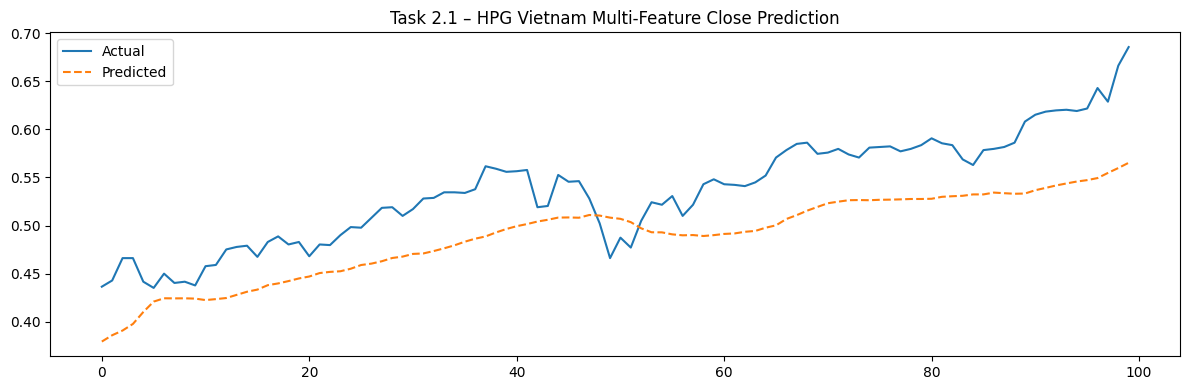

✓ Task 2.1 complete


In [54]:
# Single-feature baseline
sc_vn1 = MinMaxScaler()
d_vn1  = sc_vn1.fit_transform(df_vn[['Open']].values)
X_vn1, y_vn1 = make_sequences(d_vn1, WINDOW, target_col=0)
Xvtr1, yvtr1, Xvva1, yvva1, Xvte1, yvte1 = chrono_split(X_vn1, y_vn1)
mv1 = build_lstm((WINDOW, 1))
fit_model(mv1, Xvtr1, yvtr1, Xvva1, yvva1, epochs=60, batch_size=32)
pv1 = mv1.predict(Xvte1, verbose=0).flatten()
print("Baseline – single feature (Open):")
met_vn1 = reg_metrics(yvte1, pv1, 'Single-feature')

# Multi-feature
XVNMF, yVNMF = make_sequences(dVN, WINDOW, VN_TARGET_IDX)
XvntrMF, yvntrMF, XvnvaMF, yvnvaMF, XvnteMF, yvnteMF = chrono_split(XVNMF, yVNMF)
mvMF = build_lstm((WINDOW, len(VN_FEATURES)))
fit_model(mvMF, XvntrMF, yvntrMF, XvnvaMF, yvnvaMF, epochs=60, batch_size=32)
pvMF = mvMF.predict(XvnteMF, verbose=0).flatten()
print("\nTask 2.1 – Multi-feature (Open, High, Low, Close, Volume):")
met_vnMF = reg_metrics(yvnteMF, pvMF, 'Multi-feature')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yvnteMF[:100], label='Actual')
ax.plot(pvMF[:100],    label='Predicted', linestyle='--')
ax.set_title(f'Task 2.1 – {TICKER_VN} Vietnam Multi-Feature Close Prediction')
ax.legend(); plt.tight_layout()
plt.savefig('outputs/t2_1_vn_multifeature.png', dpi=100)
plt.show(); plt.close()
print("✓ Task 2.1 complete")


### Task 2.2 – Vietnam k-th Day Forecast (5%)

  k=1                     MAE=0.09215  RMSE=0.11006  MAPE=12.85%
  k=3                     MAE=0.14851  RMSE=0.17273  MAPE=20.85%
  k=7                     MAE=0.13610  RMSE=0.16453  MAPE=18.89%


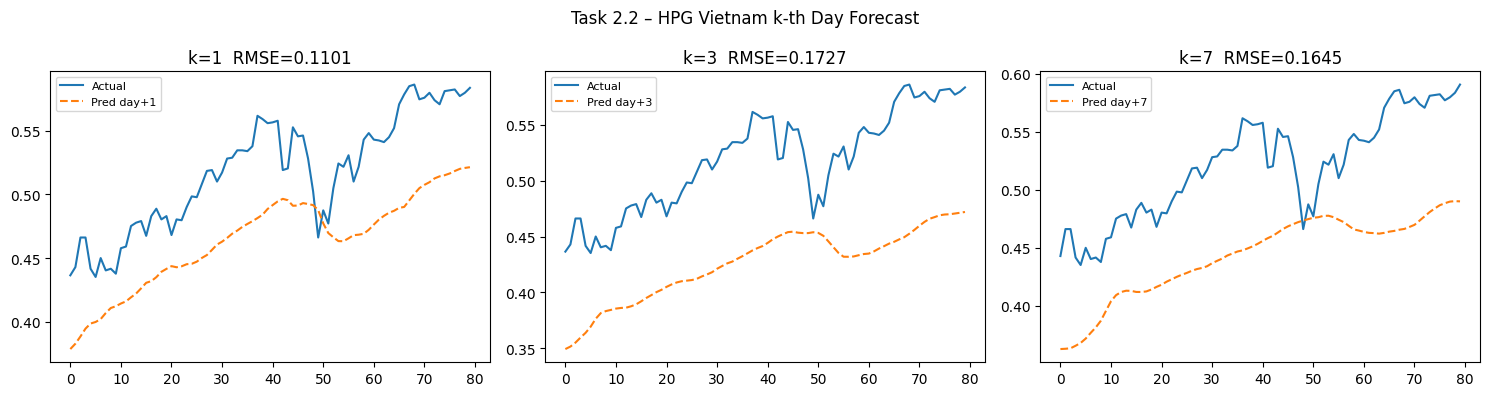

✓ Task 2.2 complete


In [55]:
results_22 = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, k in enumerate([1, 3, 7]):
    Xk, yk = make_sequences(dVN, WINDOW, VN_TARGET_IDX, k_day=k, k_days=1)
    Xtrk, ytrk, Xvak, yvak, Xtek, ytek = chrono_split(Xk, yk)
    mk = build_lstm((WINDOW, len(VN_FEATURES)))
    fit_model(mk, Xtrk, ytrk, Xvak, yvak, epochs=50, batch_size=32)
    pk = mk.predict(Xtek, verbose=0).flatten()
    results_22[k] = dict(**reg_metrics(ytek, pk, f'k={k}'), actual=ytek, pred=pk)
    axes[i].plot(ytek[:80], label='Actual')
    axes[i].plot(pk[:80],   label=f'Pred day+{k}', linestyle='--')
    axes[i].set_title(f'k={k}  RMSE={results_22[k]["rmse"]:.4f}')
    axes[i].legend(fontsize=8)

plt.suptitle(f'Task 2.2 – {TICKER_VN} Vietnam k-th Day Forecast')
plt.tight_layout()
plt.savefig('outputs/t2_2_vn_kth_day.png', dpi=100)
plt.show(); plt.close()
print("✓ Task 2.2 complete")


### Task 2.3 – Vietnam k Consecutive Days Forecast (5%)


Task 2.3 – k=3 consecutive days (HPG):
    step 1/3              MAE=0.10357  RMSE=0.12940  MAPE=14.15%
    step 2/3              MAE=0.06536  RMSE=0.08527  MAPE=9.23%
    step 3/3              MAE=0.09868  RMSE=0.12245  MAPE=13.58%

Task 2.3 – k=7 consecutive days (HPG):
    step 1/7              MAE=0.10911  RMSE=0.13343  MAPE=14.88%
    step 2/7              MAE=0.09506  RMSE=0.12103  MAPE=12.95%
    step 3/7              MAE=0.07810  RMSE=0.09764  MAPE=10.88%
    step 4/7              MAE=0.11758  RMSE=0.14483  MAPE=16.09%
    step 5/7              MAE=0.10390  RMSE=0.12836  MAPE=14.34%
    step 6/7              MAE=0.10343  RMSE=0.12742  MAPE=14.39%
    step 7/7              MAE=0.12600  RMSE=0.15252  MAPE=17.46%


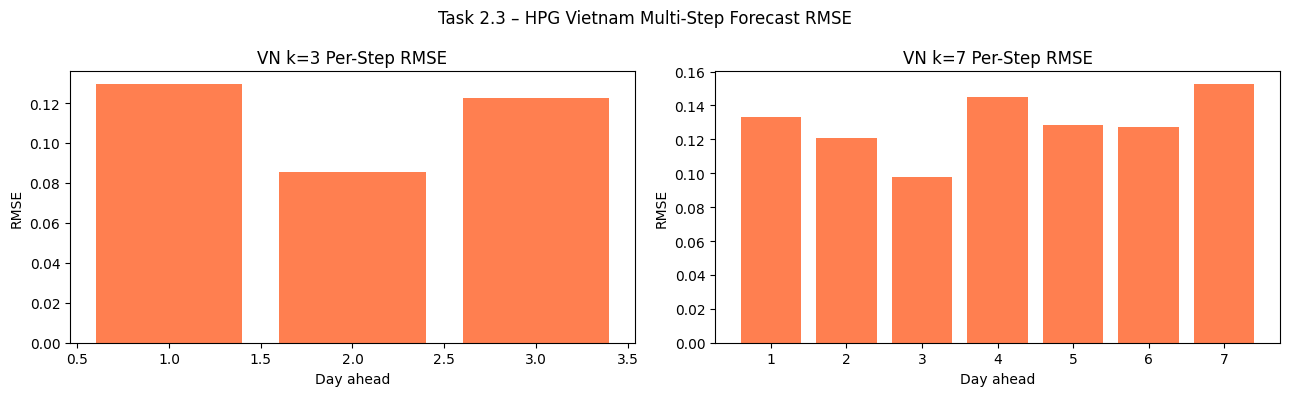


Note: Vietnam prices are in VND (thousands).
  Financial ratios & dividends are incorporated in Tasks 3-4.
✓ Task 2.3 complete


In [56]:
results_23 = {}
for k in [3, 7]:
    Xk, yk = make_sequences(dVN, WINDOW, VN_TARGET_IDX, k_day=1, k_days=k)
    Xtrk, ytrk, Xvak, yvak, Xtek, ytek = chrono_split(Xk, yk)
    mk = build_lstm((WINDOW, len(VN_FEATURES)), output_units=k)
    fit_model(mk, Xtrk, ytrk, Xvak, yvak, epochs=50, batch_size=32)
    pk = mk.predict(Xtek, verbose=0)
    print(f"\nTask 2.3 – k={k} consecutive days ({TICKER_VN}):")
    step_rmses = []
    for s in range(k):
        m = reg_metrics(ytek[:, s], pk[:, s], f'  step {s+1}/{k}')
        step_rmses.append(m['rmse'])
    results_23[k] = dict(step_rmses=step_rmses, actual=ytek, pred=pk)

# Bar chart of per-step RMSE
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, k in enumerate([3, 7]):
    axes[i].bar(range(1, k+1), results_23[k]['step_rmses'], color='coral')
    axes[i].set_xlabel('Day ahead'); axes[i].set_ylabel('RMSE')
    axes[i].set_title(f'VN k={k} Per-Step RMSE')
plt.suptitle(f'Task 2.3 – {TICKER_VN} Vietnam Multi-Step Forecast RMSE')
plt.tight_layout()
plt.savefig('outputs/t2_3_vn_rmse_by_step.png', dpi=100)
plt.show(); plt.close()

print("\nNote: Vietnam prices are in VND (thousands).")
print("  Financial ratios & dividends are incorporated in Tasks 3-4.")
print("✓ Task 2.3 complete")


---
## Task 3 – Trading Signal Identification for Vietnam Market (20%)

### Methodology

**Label generation:**
- **Buy (Task 3.1):** The current Close price is the local minimum within a ±5-day symmetric window (i.e., lower than the 5 days before and 5 days after). This is a historical price trough — an optimal entry point.
- **Sell (Task 3.2):** The current Close is the local maximum within the same ±5-day window — an optimal exit point.

**Justification:** Using local extrema provides data-driven ground-truth labels that represent actual best-case entry/exit timings, without requiring forward-looking heuristics.

**Feature engineering:** Standard technical indicators are added to improve signal detection — SMA-10, SMA-20, MACD, RSI-14, Bollinger Band %, Volume change.

**Model:** Bidirectional LSTM classifier (sigmoid output = buy/sell probability).

**Class imbalance:** Handled via weighted loss (class weight inversely proportional to class frequency).

**Evaluation:** F1-score, precision, recall (accuracy alone is misleading with imbalanced classes).


### Task 3.0 – Feature Engineering & Labelling

HPG rows after NA drop : 3789
Buy signals            : 272
Sell signals           : 271


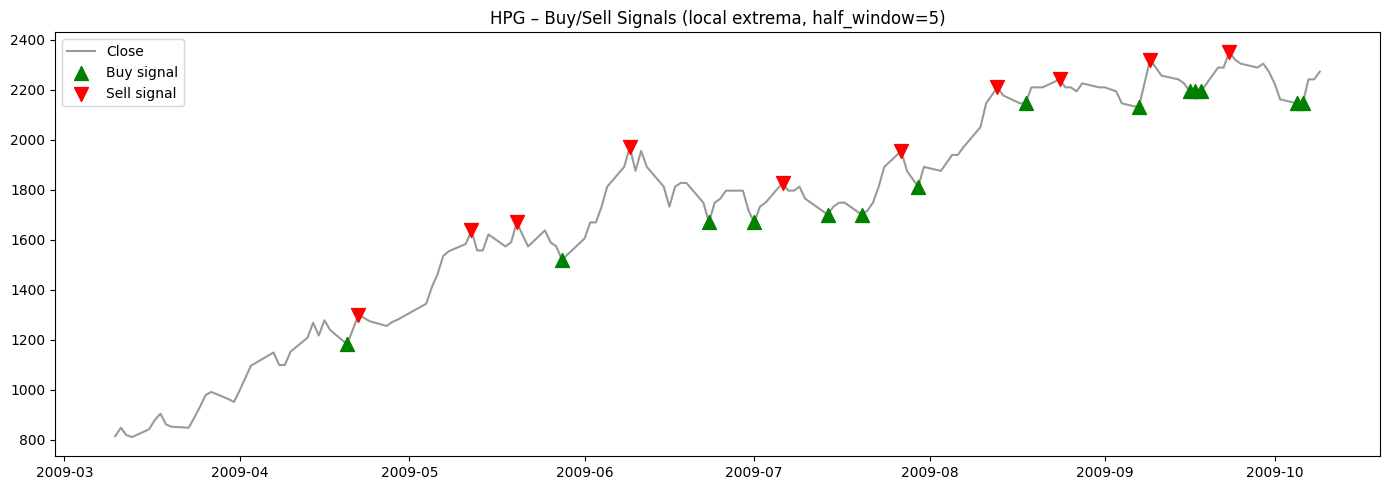

✓ Labelling complete


In [57]:
def add_technical_indicators(df):
    """Add SMA, EMA, MACD, RSI, Bollinger Bands, Vol change."""
    df = df.copy()
    c  = df['Close']

    df['SMA_10']   = c.rolling(10).mean()
    df['SMA_20']   = c.rolling(20).mean()
    df['EMA_12']   = c.ewm(span=12, adjust=False).mean()
    df['EMA_26']   = c.ewm(span=26, adjust=False).mean()
    df['MACD']     = df['EMA_12'] - df['EMA_26']
    df['MACD_sig'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_hist']= df['MACD'] - df['MACD_sig']

    delta  = c.diff()
    gain   = delta.clip(lower=0).rolling(14).mean()
    loss   = (-delta).clip(lower=0).rolling(14).mean()
    df['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-8)))

    bb_mid = c.rolling(20).mean()
    bb_std = c.rolling(20).std()
    df['BB_pct']  = (c - bb_mid + 2*bb_std) / (4*bb_std + 1e-8)
    df['Vol_chg'] = df['Volume'].pct_change().clip(-5, 5)

    return df

def label_buy_sell(df, half_window=5):
    """
    Buy  = local min within ±half_window (price at a trough).
    Sell = local max within ±half_window (price at a peak).
    """
    prices = df['Close'].values
    n      = len(prices)
    buy    = np.zeros(n, dtype=int)
    sell   = np.zeros(n, dtype=int)
    for i in range(half_window, n - half_window):
        w = prices[i - half_window : i + half_window + 1]
        if prices[i] == w.min(): buy[i]  = 1
        if prices[i] == w.max(): sell[i] = 1
    df = df.copy()
    df['buy_signal']  = buy
    df['sell_signal'] = sell
    return df

def clean_features(df, feature_cols):
    """Replace inf, forward-fill NaN, fallback to 0."""
    arr = df[feature_cols].values.astype(float)
    arr = np.where(np.isinf(arr), np.nan, arr)
    for col in range(arr.shape[1]):
        mask = np.isnan(arr[:, col])
        if mask.any():
            arr[:, col] = pd.Series(arr[:, col]).ffill().fillna(0).values
    return arr

df_sig = add_technical_indicators(df_vn)
df_sig = label_buy_sell(df_sig, half_window=5)
df_sig = df_sig.dropna().reset_index(drop=True)

print(f"HPG rows after NA drop : {len(df_sig)}")
print(f"Buy signals            : {df_sig.buy_signal.sum()}")
print(f"Sell signals           : {df_sig.sell_signal.sum()}")

# Visualise signals on a 150-day window
sample = df_sig[300:450].copy()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample.TradingDate, sample.Close, color='gray', alpha=0.8, label='Close')
ax.scatter(sample.TradingDate[sample.buy_signal==1],
           sample.Close[sample.buy_signal==1],
           color='green', marker='^', s=100, zorder=5, label='Buy signal')
ax.scatter(sample.TradingDate[sample.sell_signal==1],
           sample.Close[sample.sell_signal==1],
           color='red', marker='v', s=100, zorder=5, label='Sell signal')
ax.legend(); ax.set_title(f'HPG – Buy/Sell Signals (local extrema, half_window=5)')
plt.tight_layout()
plt.savefig('outputs/t3_signals_labels.png', dpi=100)
plt.show(); plt.close()
print("✓ Labelling complete")


### Task 3.1 – Buying Signal Identification (10%)

Class weights (buy): {0: 1.0, 1: np.float64(12.328281185134646)}
Validation-selected threshold (buy): 0.500  |  val-F1=0.126

Task 3.1 – Buy Signal Classification Report:
              precision    recall  f1-score   support

      No Buy      0.939     0.994     0.966       530
         Buy      0.250     0.029     0.051        35

    accuracy                          0.935       565
   macro avg      0.595     0.511     0.509       565
weighted avg      0.897     0.935     0.909       565



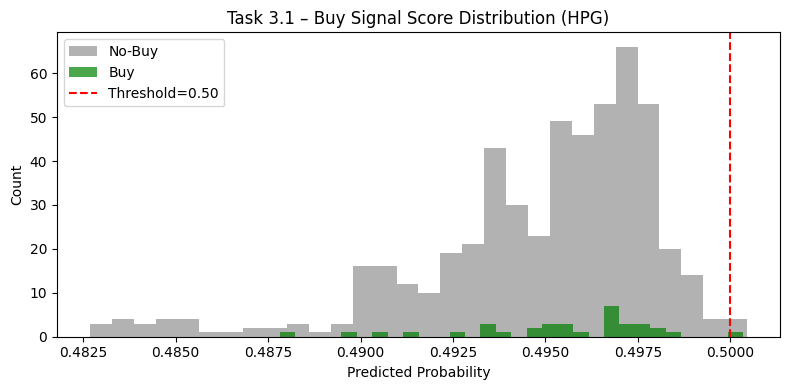

✓ Task 3.1 complete


In [58]:
SIG_FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume',
                'SMA_10', 'SMA_20', 'MACD', 'MACD_sig', 'RSI', 'BB_pct', 'Vol_chg']
WIN_SIG = 20

arr_clean = clean_features(df_sig, SIG_FEATURES)

def make_cls_seq(X_raw, y_raw, window=20):
    X, y = [], []
    for i in range(window, len(X_raw)):
        X.append(X_raw[i-window:i]); y.append(y_raw[i])
    return np.array(X), np.array(y)

def scale_seq_train_only(Xtr, Xva, Xte):
    """Fit scaler on training split only, then transform val/test."""
    n_feat = Xtr.shape[-1]
    sc = MinMaxScaler()
    Xtr_s = sc.fit_transform(Xtr.reshape(-1, n_feat)).reshape(Xtr.shape)
    Xva_s = sc.transform(Xva.reshape(-1, n_feat)).reshape(Xva.shape)
    Xte_s = sc.transform(Xte.reshape(-1, n_feat)).reshape(Xte.shape)
    return Xtr_s, Xva_s, Xte_s, sc

# ── Task 3.1 – Buy signal ──────────────────────────────────
Xbuy_raw, ybuy = make_cls_seq(arr_clean, df_sig['buy_signal'].values, WIN_SIG)
Xbtr_raw, ybtr, Xbva_raw, ybva, Xbte_raw, ybte = chrono_split(Xbuy_raw, ybuy)
Xbtr, Xbva, Xbte, sc_buy = scale_seq_train_only(Xbtr_raw, Xbva_raw, Xbte_raw)

pos_rate = ybtr.mean()
cw_buy   = {0: 1.0, 1: max(1.0, (1 - pos_rate) / (pos_rate + 1e-8))}
print(f"Class weights (buy): {cw_buy}")

clf_buy = build_classifier((WIN_SIG, len(SIG_FEATURES)))
fit_model(clf_buy, Xbtr, ybtr, Xbva, ybva,
          class_weight=cw_buy, epochs=50, batch_size=32)

prob_buy_va = clf_buy.predict(Xbva, verbose=0).flatten()
buy_thr, buy_f1_va = best_f1_threshold(ybva, prob_buy_va)

prob_buy = clf_buy.predict(Xbte, verbose=0).flatten()
pred_buy = (prob_buy >= buy_thr).astype(int)

print(f"Validation-selected threshold (buy): {buy_thr:.3f}  |  val-F1={buy_f1_va:.3f}")
print("\nTask 3.1 – Buy Signal Classification Report:")
print(classification_report(ybte, pred_buy,
                            target_names=['No Buy', 'Buy'], digits=3,
                            zero_division=0))

# Probability score distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prob_buy[ybte == 0], bins=30, alpha=0.6, label='No-Buy', color='gray')
ax.hist(prob_buy[ybte == 1], bins=30, alpha=0.7, label='Buy', color='green')
ax.axvline(buy_thr, color='red', linestyle='--', label=f'Threshold={buy_thr:.2f}')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Count')
ax.set_title('Task 3.1 – Buy Signal Score Distribution (HPG)')
ax.legend(); plt.tight_layout()
plt.savefig('outputs/t3_1_buy_probs.png', dpi=100)
plt.show(); plt.close()
print("✓ Task 3.1 complete")


### Task 3.2 – Selling Signal Identification (10%)

Validation-selected threshold (sell): 0.550  |  val-F1=0.187
Task 3.2 – Sell Signal Classification Report:
              precision    recall  f1-score   support

     No Sell      0.934     0.836     0.882       529
        Sell      0.054     0.139     0.078        36

    accuracy                          0.791       565
   macro avg      0.494     0.487     0.480       565
weighted avg      0.878     0.791     0.831       565



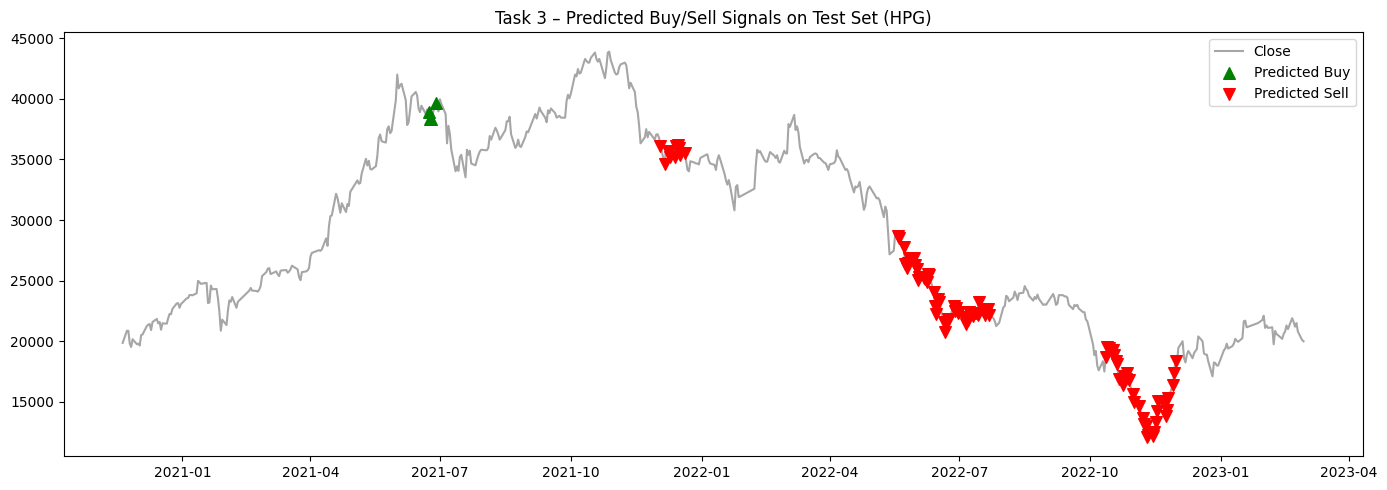

✓ Task 3.2 complete


In [59]:
# Mirror of Task 3.1 for sell signals
Xsell_raw, ysell = make_cls_seq(arr_clean, df_sig['sell_signal'].values, WIN_SIG)
Xstr_raw, ystr, Xsva_raw, ysva, Xste_raw, yste = chrono_split(Xsell_raw, ysell)
Xstr, Xsva, Xste, sc_sell = scale_seq_train_only(Xstr_raw, Xsva_raw, Xste_raw)

pos_rate_s = ystr.mean()
cw_sell    = {0: 1.0, 1: max(1.0, (1 - pos_rate_s) / (pos_rate_s + 1e-8))}

clf_sell = build_classifier((WIN_SIG, len(SIG_FEATURES)))
fit_model(clf_sell, Xstr, ystr, Xsva, ysva,
          class_weight=cw_sell, epochs=50, batch_size=32)

prob_sell_va = clf_sell.predict(Xsva, verbose=0).flatten()
sell_thr, sell_f1_va = best_f1_threshold(ysva, prob_sell_va)

prob_sell = clf_sell.predict(Xste, verbose=0).flatten()
pred_sell = (prob_sell >= sell_thr).astype(int)

print(f"Validation-selected threshold (sell): {sell_thr:.3f}  |  val-F1={sell_f1_va:.3f}")
print("Task 3.2 – Sell Signal Classification Report:")
print(classification_report(yste, pred_sell,
                            target_names=['No Sell', 'Sell'], digits=3,
                            zero_division=0))

# Combined buy/sell on test portion
n_te = len(Xbte)
ts_start = len(df_sig) - n_te
x_dates = df_sig['TradingDate'].values[ts_start : ts_start + len(prob_buy)]
close_t = df_sig['Close'].values[ts_start : ts_start + len(prob_buy)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x_dates, close_t, color='gray', alpha=0.7, label='Close')
bi = np.where(pred_buy == 1)[0]
si = np.where(pred_sell == 1)[0]
ax.scatter(x_dates[bi], close_t[bi], color='green', marker='^', s=70, zorder=5, label='Predicted Buy')
ax.scatter(x_dates[si], close_t[si], color='red', marker='v', s=70, zorder=5, label='Predicted Sell')
ax.legend(); ax.set_title('Task 3 – Predicted Buy/Sell Signals on Test Set (HPG)')
plt.tight_layout()
plt.savefig('outputs/t3_combined_signals.png', dpi=100)
plt.show(); plt.close()
print("✓ Task 3.2 complete")


---
## Task 4 – Portfolio Composition, Risk Management & Optimisation (30%)

### Methodology

**Task 4.1 – Profitable stock selection:**  
Composite profitability score = 35% × norm(annual return) + 30% × norm(Sharpe ratio) + 20% × norm(ROE) + 15% × norm(ROA). Financial ratios sourced from `financial-ratio/` folder. Dividend history provides additional yield signal.

**Task 4.2 – Risk management:**  
Risk score = 40% × norm(annual volatility) + 35% × norm(|max drawdown|) + 25% × (1 − norm(Sharpe)). Companies in the top 30th percentile of risk score are excluded from prudent portfolios.

**Task 4.3 – Portfolio optimisation (Markowitz):**  
Two strategies using scipy constrained optimisation:
- **Max Sharpe** (risk-taking investor): maximise (μ − r_f) / σ
- **Min Variance** (prudent investor): minimise σ² subject to Σwᵢ = 1, 0 ≤ wᵢ ≤ 1

Efficient frontier computed across the full return–risk space.


### Task 4.1 – Profitable Stock Selection (10%)

Financial ratios loaded for 1246 companies
Task 4.1 – Top Profitable Companies (scored on train period):
ticker  ann_ret_train  sharpe_train    roe  profit_score  realized_test_ret
   TBH         4.6260        5.5339 0.0000        0.7771            -0.9186
   SSH         2.9179        4.5487 0.0903        0.6352            -0.4279
   THD         2.2202        3.6181 0.2687        0.5686            -0.7778
   KSF         2.2158        3.1898 0.1065        0.5393            -0.6059
   SCG         1.8921        2.4041 0.1397        0.4873            -0.2820
   GMA         1.1604        3.1282 0.0855        0.4713            -0.1265
   IDP         1.0886        1.5356 0.6997        0.4433             0.1938
   BVL         1.5991        1.5050 0.2483        0.4431            -0.7059


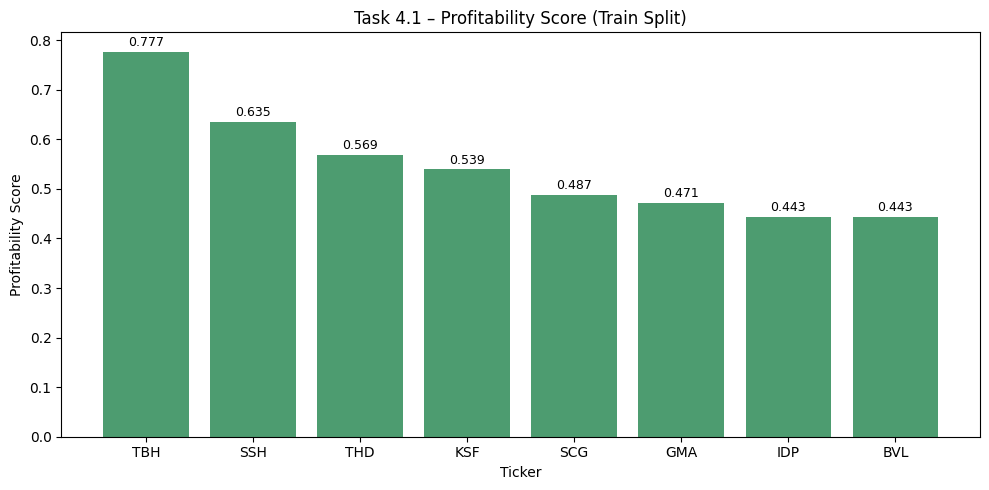

✓ Task 4.1 complete


In [60]:
# ── Load financial ratios ─────────────────────────────────
fin_data = {}
for fname in os.listdir(VN_FIN_DIR):
    ticker = fname.split('-')[0]
    try:
        fdf = pd.read_csv(os.path.join(VN_FIN_DIR, fname), index_col=0)
        fdf = fdf[['roe', 'roa']].apply(pd.to_numeric, errors='coerce').dropna()
        if len(fdf) > 0:
            fin_data[ticker] = {
                'roe': float(fdf.roe.mean()),
                'roa': float(fdf.roa.mean())
            }
    except Exception:
        pass
print(f"Financial ratios loaded for {len(fin_data)} companies")

# ── Time-series split for portfolio scoring ───────────────
# Use train period for scoring/optimisation and hold out the most recent period for evaluation.
TEST_DAYS = 252  # ~1 trading year

port_rows = []
for ticker, df_t in vn_dfs.items():
    closes = df_t['Close'].values.astype(float)
    if len(closes) < TEST_DAYS + 60:
        continue

    train_close = closes[:-TEST_DAYS]
    test_close  = closes[-TEST_DAYS:]

    r_train = np.diff(np.log(train_close + 1e-8))
    if len(r_train) < 30:
        continue

    ann_ret_train = r_train.mean() * 252
    ann_vol_train = r_train.std() * np.sqrt(252)
    sharpe_train  = ann_ret_train / (ann_vol_train + 1e-8)

    cum_train = np.cumprod(1 + r_train)
    runmax_train = np.maximum.accumulate(cum_train)
    max_dd_train = float(((cum_train - runmax_train) / (runmax_train + 1e-8)).min())

    # Out-of-sample return (simple proxy for projected profitability validation)
    realized_test_ret = float((test_close[-1] - test_close[0]) / (test_close[0] + 1e-8))

    port_rows.append({
        'ticker': ticker,
        'ann_ret_train': ann_ret_train,
        'ann_vol_train': ann_vol_train,
        'sharpe_train': sharpe_train,
        'max_dd_train': max_dd_train,
        'realized_test_ret': realized_test_ret,
        'roe': fin_data.get(ticker, {}).get('roe', 0.0),
        'roa': fin_data.get(ticker, {}).get('roa', 0.0),
    })

port_df = pd.DataFrame(port_rows).dropna().reset_index(drop=True)

# ── Profitability score (train-period features only) ──────
port_df['profit_score'] = (
    0.35 * norm_series(port_df.ann_ret_train) +
    0.30 * norm_series(port_df.sharpe_train) +
    0.20 * norm_series(port_df.roe) +
    0.15 * norm_series(port_df.roa)
)

TOP_N = min(8, len(port_df))
top_stocks = port_df.nlargest(TOP_N, 'profit_score').reset_index(drop=True)

print("Task 4.1 – Top Profitable Companies (scored on train period):")
print(top_stocks[['ticker', 'ann_ret_train', 'sharpe_train', 'roe',
                  'profit_score', 'realized_test_ret']]
      .to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_stocks.ticker, top_stocks.profit_score, color='seagreen', alpha=0.85)
ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=9)
ax.set_xlabel('Ticker'); ax.set_ylabel('Profitability Score')
ax.set_title('Task 4.1 – Profitability Score (Train Split)')
plt.tight_layout()
plt.savefig('outputs/t4_1_profitability.png', dpi=100)
plt.show(); plt.close()
print("✓ Task 4.1 complete")


### Task 4.2 – Risk Management (10%)

Task 4.2 – Risk Management (train split):
  ticker  ann_vol_train  max_dd_train  risk_score  realized_test_ret
FUCTVGF3         0.1156        0.0000      0.1463             0.4000
     MTB         0.0096        0.0000      0.1580             0.0417
     DDG         0.2086       -0.0968      0.1598             0.2011
     FIR         0.2414       -0.1925      0.1616             0.4152
     MQB         0.0074        0.0000      0.1654             0.0000
     NDW         0.0035        0.0000      0.1671             0.2500
     LNC         0.0062        0.0000      0.1674             0.0000
     TQW         0.0067        0.0000      0.1677             0.0000
FUEVFVND         0.2517       -0.1480      0.1721            -0.2542
     GMA         0.3709       -0.3211      0.1730            -0.1265
     BNW         0.0647        0.0000      0.1794             0.0000
     BLW         0.1295        0.0000      0.1839             0.2182
     SSH         0.6415       -0.1993      0.1868            

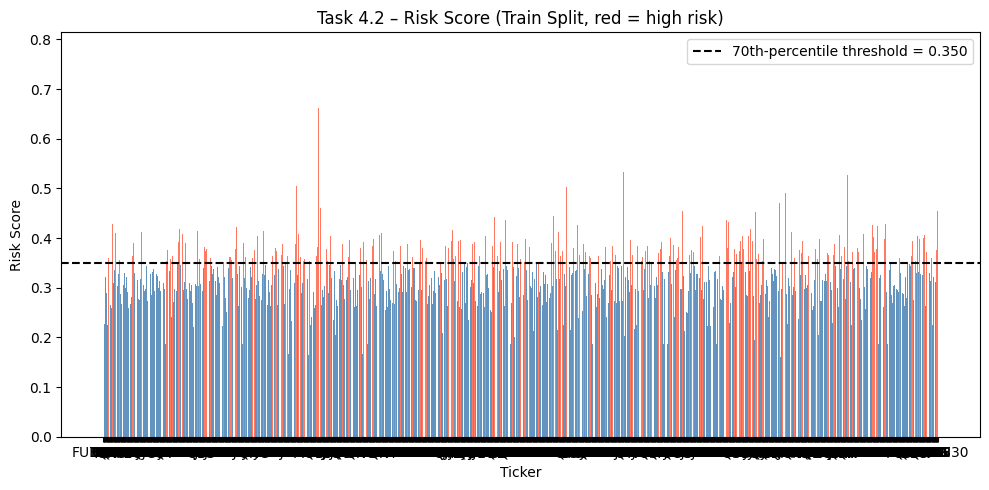

✓ Task 4.2 complete


In [61]:
# Risk score: higher = riskier (exclude from prudent portfolio)
# Computed from train split only to respect time-series validation.
port_df['risk_score'] = (
    0.40 * norm_series(port_df.ann_vol_train) +
    0.35 * norm_series(-port_df.max_dd_train) +   # larger drawdown magnitude => riskier
    0.25 * (1 - norm_series(port_df.sharpe_train))
)

RISK_THRESHOLD = port_df.risk_score.quantile(0.70)
risky_list = port_df[port_df.risk_score >= RISK_THRESHOLD].ticker.tolist()
safe_list  = port_df[port_df.risk_score < RISK_THRESHOLD].ticker.tolist()

print("Task 4.2 – Risk Management (train split):")
print(port_df.sort_values('risk_score')[['ticker', 'ann_vol_train', 'max_dd_train',
                                         'risk_score', 'realized_test_ret']]
      .to_string(index=False, float_format='%.4f'))
print(f"\nHigh-risk companies (top 30%, excluded from prudent portfolio): {risky_list}")
print(f"Lower-risk companies (eligible for optimisation)              : {safe_list}")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if t in risky_list else 'steelblue' for t in port_df.ticker]
ax.bar(port_df.ticker, port_df.risk_score, color=colors, alpha=0.85)
ax.axhline(RISK_THRESHOLD, color='black', linestyle='--',
           label=f'70th-percentile threshold = {RISK_THRESHOLD:.3f}')
ax.set_xlabel('Ticker'); ax.set_ylabel('Risk Score')
ax.set_title('Task 4.2 – Risk Score (Train Split, red = high risk)')
ax.legend(); plt.tight_layout()
plt.savefig('outputs/t4_2_risk.png', dpi=100)
plt.show(); plt.close()
print("✓ Task 4.2 complete")


### Task 4.3 – Portfolio Composition & Markowitz Optimisation (10%)

Eligible tickers for optimisation: ['TBH', 'SSH', 'THD', 'KSF', 'SCG', 'GMA', 'IDP']
Train return matrix shape: (95, 7)
Test  return matrix shape: (251, 7)
Final eligible tickers    : ['TBH', 'SSH', 'THD', 'KSF', 'SCG', 'GMA', 'IDP']

── Max Sharpe Portfolio (Risk-Taking) ──
  TBH: 41.8%
  SSH: 16.5%
  THD: 9.9%
  KSF: 9.6%
  GMA: 22.1%
  Train: Return=4.718  Vol=0.460  Sharpe=10.153
  Test : Return=-1.416  Vol=0.334  Sharpe=-4.388

── Min Variance Portfolio (Prudent) ──
  TBH: 24.6%
  THD: 10.6%
  KSF: 21.0%
  GMA: 29.0%
  IDP: 13.4%
  Train: Return=3.570  Vol=0.401  Sharpe=8.782
  Test : Return=-0.999  Vol=0.259  Sharpe=-4.044


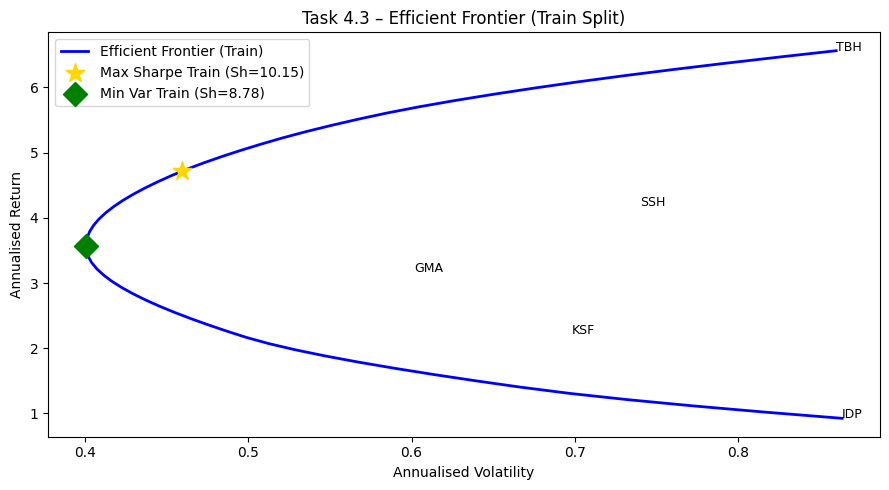

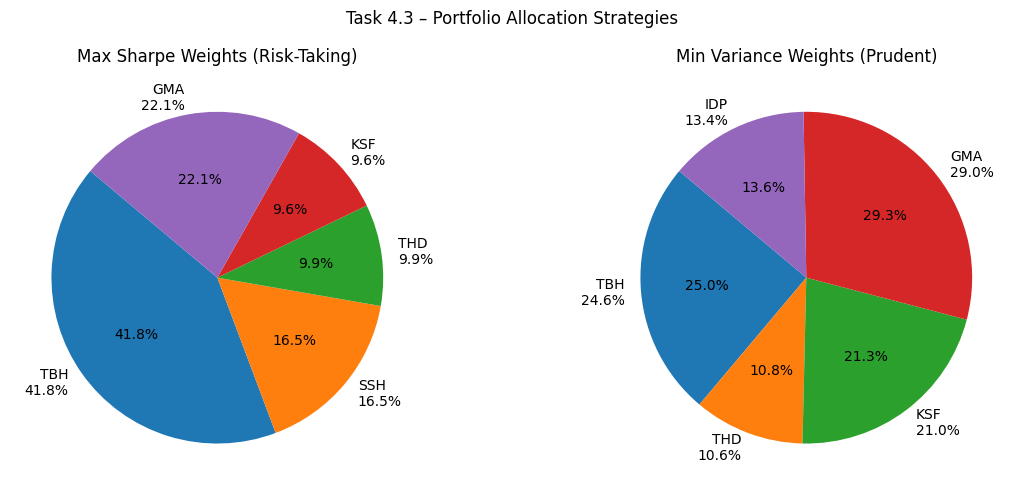


Key Insight:
  Optimisation is done on train returns; performance is reported on held-out test returns.
  Risk-taking  → Max Sharpe typically targets higher expected return at higher volatility.
  Prudent      → Min Variance prioritises lower volatility and stability.
✓ Task 4.3 complete


In [62]:
# Eligible = top profitable AND NOT high-risk
ELIGIBLE = [t for t in top_stocks.ticker if t not in risky_list]
if len(ELIGIBLE) < 2:
    ELIGIBLE = list(top_stocks.ticker[:4])
print(f"Eligible tickers for optimisation: {ELIGIBLE}")

TEST_DAYS = 252

def split_returns_for_portfolio(ticker, test_days=252):
    closes = vn_dfs[ticker]['Close'].values.astype(float)
    if len(closes) < test_days + 60:
        return None, None
    train_close = closes[:-test_days]
    test_close  = closes[-test_days:]
    r_train = np.diff(np.log(train_close + 1e-8))
    r_test  = np.diff(np.log(test_close + 1e-8))
    if len(r_train) < 30 or len(r_test) < 20:
        return None, None
    return pd.Series(r_train), pd.Series(r_test)

# ── Build train/test return matrices ──────────────────────
ret_train_dict, ret_test_dict = {}, {}
for t in ELIGIBLE:
    tr, te = split_returns_for_portfolio(t, TEST_DAYS)
    if tr is not None:
        ret_train_dict[t] = tr
        ret_test_dict[t]  = te

ret_train = pd.DataFrame(ret_train_dict).dropna()
ret_test  = pd.DataFrame(ret_test_dict).dropna()

# Keep only common columns after dropna
common_cols = [c for c in ret_train.columns if c in ret_test.columns]
ret_train = ret_train[common_cols]
ret_test  = ret_test[common_cols]
ELIGIBLE = common_cols

print(f"Train return matrix shape: {ret_train.shape}")
print(f"Test  return matrix shape: {ret_test.shape}")
print(f"Final eligible tickers    : {ELIGIBLE}")

mu_vec   = ret_train.mean().values * 252      # expected annual return (train)
cov_mat  = ret_train.cov().values  * 252      # annual covariance (train)
n_assets = len(ELIGIBLE)

w0     = np.ones(n_assets) / n_assets
bounds = tuple((0.0, 1.0) for _ in range(n_assets))
cons   = ({'type': 'eq', 'fun': lambda w: w.sum() - 1},)
RF = 0.05

def stats_from_mu_cov(w, mu, cov, rf=0.05):
    ret = w @ mu
    vol = np.sqrt(w @ cov @ w)
    sharpe = (ret - rf) / (vol + 1e-8)
    return ret, vol, sharpe

def neg_sharpe_train(w):
    return -stats_from_mu_cov(w, mu_vec, cov_mat, RF)[2]

def port_vol_train(w):
    return np.sqrt(w @ cov_mat @ w)

# ── Optimise on train split ───────────────────────────────
res_ms = sco.minimize(neg_sharpe_train, w0, method='SLSQP',
                      bounds=bounds, constraints=cons)
res_mv = sco.minimize(port_vol_train, w0, method='SLSQP',
                      bounds=bounds, constraints=cons)

w_ms = res_ms.x
w_mv = res_mv.x

r_ms_tr, v_ms_tr, sh_ms_tr = stats_from_mu_cov(w_ms, mu_vec, cov_mat, RF)
r_mv_tr, v_mv_tr, sh_mv_tr = stats_from_mu_cov(w_mv, mu_vec, cov_mat, RF)

# ── Evaluate out-of-sample on held-out test split ─────────
mu_test  = ret_test.mean().values * 252
cov_test = ret_test.cov().values  * 252

r_ms_te, v_ms_te, sh_ms_te = stats_from_mu_cov(w_ms, mu_test, cov_test, RF)
r_mv_te, v_mv_te, sh_mv_te = stats_from_mu_cov(w_mv, mu_test, cov_test, RF)

print("\n── Max Sharpe Portfolio (Risk-Taking) ──")
for t, w in zip(ELIGIBLE, w_ms):
    if w > 0.01:
        print(f"  {t}: {w*100:.1f}%")
print(f"  Train: Return={r_ms_tr:.3f}  Vol={v_ms_tr:.3f}  Sharpe={sh_ms_tr:.3f}")
print(f"  Test : Return={r_ms_te:.3f}  Vol={v_ms_te:.3f}  Sharpe={sh_ms_te:.3f}")

print("\n── Min Variance Portfolio (Prudent) ──")
for t, w in zip(ELIGIBLE, w_mv):
    if w > 0.01:
        print(f"  {t}: {w*100:.1f}%")
print(f"  Train: Return={r_mv_tr:.3f}  Vol={v_mv_tr:.3f}  Sharpe={sh_mv_tr:.3f}")
print(f"  Test : Return={r_mv_te:.3f}  Vol={v_mv_te:.3f}  Sharpe={sh_mv_te:.3f}")

# ── Efficient Frontier (train split) ──────────────────────
ef_r, ef_v = [], []
for target_r in np.linspace(mu_vec.min(), mu_vec.max(), 60):
    c2 = [
        {'type': 'eq', 'fun': lambda w: w.sum() - 1},
        {'type': 'eq', 'fun': lambda w, r=target_r: w @ mu_vec - r}
    ]
    res = sco.minimize(port_vol_train, w0, method='SLSQP',
                       bounds=bounds, constraints=c2)
    if res.success:
        ef_r.append(target_r)
        ef_v.append(res.fun)

# ── Plots ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
if ef_v:
    ax.plot(ef_v, ef_r, 'b-', linewidth=2, label='Efficient Frontier (Train)')
ax.scatter([v_ms_tr], [r_ms_tr], color='gold', s=200, zorder=5, marker='*',
           label=f'Max Sharpe Train (Sh={sh_ms_tr:.2f})')
ax.scatter([v_mv_tr], [r_mv_tr], color='green', s=150, zorder=5, marker='D',
           label=f'Min Var Train (Sh={sh_mv_tr:.2f})')
for i, t in enumerate(ELIGIBLE):
    ax.annotate(t, (np.sqrt(cov_mat[i, i]), mu_vec[i]), fontsize=9)
ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Return')
ax.set_title('Task 4.3 – Efficient Frontier (Train Split)')
ax.legend(); plt.tight_layout()
plt.savefig('outputs/t4_3_efficient_frontier.png', dpi=100)
plt.show(); plt.close()

fig2, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, weights, title in [
    (a1, w_ms, 'Max Sharpe Weights (Risk-Taking)'),
    (a2, w_mv, 'Min Variance Weights (Prudent)')
]:
    lbls = [f'{t}\n{w*100:.1f}%' for t, w in zip(ELIGIBLE, weights) if w > 0.01]
    sizes = [w for w in weights if w > 0.01]
    if sizes:
        ax.pie(sizes, labels=lbls, autopct='%1.1f%%', startangle=140)
    ax.set_title(title)
plt.suptitle('Task 4.3 – Portfolio Allocation Strategies')
plt.tight_layout()
plt.savefig('outputs/t4_3_portfolio_alloc.png', dpi=100)
plt.show(); plt.close()

print("\nKey Insight:")
print("  Optimisation is done on train returns; performance is reported on held-out test returns.")
print("  Risk-taking  → Max Sharpe typically targets higher expected return at higher volatility.")
print("  Prudent      → Min Variance prioritises lower volatility and stability.")
print("✓ Task 4.3 complete")
